In [7]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

In [17]:
def create_grid(domain_size_x, domain_size_y, num_points):
    
    x_grid, y_grid = np.meshgrid(
        np.linspace(1e-20, domain_size_x, num_points), # Начинаем не с 0 что бы избежать деления на 0
        np.linspace(-domain_size_y, domain_size_y, 2 * num_points)
    )
    return x_grid, y_grid

def plot(x_grid, y_grid, concentration: np.ndarray, min_concentration: float, fill: bool = True) -> None:
    """
    Отрисовывает график концентрации.

    :param x_grid: Сетка по оси X.
    :param y_grid: Сетка по оси Y.
    :param concentration: Массив концентраций.
    :param min_concentration: Минимальное значение концентрации для отображения.
    :param fill: Заливка графика, True по умолчанию.
    """
    concentration = np.where(concentration <= 0, 1e-50, concentration)
    levels = np.geomspace(min_concentration, concentration.max(), 20)  # Логарифмические уровни
    if fill:
        plt.contourf(
            x_grid, y_grid, concentration,
            levels=levels,
            cmap='cividis',  # Цветовая карта
            norm=LogNorm(vmin=min_concentration, vmax=concentration.max()),  # Логарифмическая нормализация
        )
    else:
        plt.contour(
            x_grid, y_grid, concentration,
            levels=levels,
            cmap='cividis',  # Цветовая карта
            norm=LogNorm(vmin=min_concentration, vmax=concentration.max()),  # Логарифмическая нормализация
            linewidths=1  # Толщина линий
        )
    cbar = plt.colorbar()
    cbar.ax.set_yscale('log')
    return plt


In [42]:
domain_size_x, domain_size_y = 1000, 500
num_points = 1000

Q = 10            # Интенсивность источника
x0, y0=100, 0   # Координаты источника
u, v =0, 0    # Скорость ветра
mu=1            # Коэффициент турбулентной диффузии
sigma=0.05      # Коэффициент поглощения
E = 10e-12      # Степень точности

# Создание сетки
x_grid, y_grid = create_grid(domain_size_x, domain_size_y, num_points)

$$ |r - r_0| \approx \frac{Q^2}{E^2} \frac{1}{2 \pi \mu (4 \sigma \mu + u^2 + v^2)}, $$

In [29]:
dx = x_grid - x0
dy = y_grid - y0
dr = (Q**2) / ((E**2) * 2 * np.pi * mu * (4 * sigma * mu + u**2 + v**2))
du = np.sqrt(u**2 + v**2)

$\tilde{x}_1 = x / 2$, где $x = \sqrt{\frac{\beta}{\mu}} |r - r_0|$

In [30]:
beta = sigma + (u**2 + v**2) / (4 * mu)
x = np.sqrt(beta / mu) * dr
x1_tide = x/2

$\alpha = 1 + 3.5156229 t^2 + 3.0899424 t^4 + 1.2067492 t^6 + 0.2659732 t^8 + 0.0360768 t^{10} + 0.0045813 t^{12},$

$\text{ где } t = x / 3.75.$


$$ \tilde{k}_1(x) = -\alpha \ln(\tilde{x}_1) - 0.5721566 + 0.4227842 \tilde{x}_1^2 + 0.23069756 \tilde{x}_1^4 + 0.0348589 \tilde{x}_1^6 + 0.00262698 \tilde{x}_1^8 + 0.0001075 \tilde{x}_1^{10} + 0.000074 \tilde{x}_1^{12}. $$

In [31]:
t = x/3.75
alpha = (1 + 3.5156229 * t**2  + 3.0899424 * t**4 +
             1.2067492 * t**6  + 0.2659732 * t**8 +
             0.0360768 * t**10 + 0.0045813 * t**12)

k1_tide = (-alpha * np.log(x1_tide) - 0.5721566 +
            0.4227842 * x1_tide**2  + 0.23069756 * x1_tide**4 +
            0.0348589 * x1_tide**6  + 0.00262698 * x1_tide**8 +
            0.0001075 * x1_tide**10 + 0.000074   * x1_tide**12)


$$ \Phi = \frac{Q}{2 \pi \mu} \exp \left[ \frac{|\vec{u}| \cdot |\vec{r} - \vec{r_0}|}{2 \mu} \right] \tilde{k}_1(x)$$

In [35]:
concentration = np.zeros_like(x)
mask_lt2 = x < 2  # маска для x < 2 (lt - less then)
exp_factor = np.exp((du*dr) / (2 * mu))
concentration[mask_lt2] = (Q / (2 * np.pi * mu)) * k1_tide * exp_factor
print(concentration)

0.0


/tmp/ipykernel_112180/3885591255.py:3: RuntimeWarning: overflow encountered in exp
  exp_factor = np.exp((du*dr) / (2 * mu))


TypeError: Input z must be 2D, not 0D

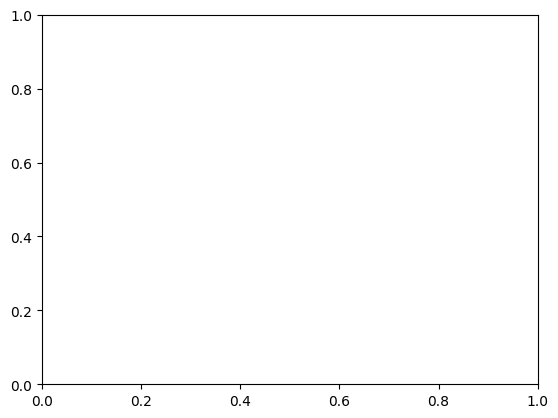

In [33]:
# Визуализация
plt = plot(x_grid, y_grid, concentration, min_concentration=1e-40)
plt.show()

In [ ]:
mask_lt2 = x_val < 2
x_lt2 = x_val[mask_lt2]
if x_lt2.size > 0:
    tilde_x1 = x_lt2 / 2
    t = x_lt2 / 3.75
    alpha = (1 + 3.5156229 * t**2 + 3.0899424 * t**4 +
                1.2067492 * t**6 + 0.2659732 * t**8 +
                0.0360768 * t**10 + 0.0045813 * t**12)
    ln_tilde_x1 = np.log(tilde_x1)
    tilde_k1 = (-alpha * ln_tilde_x1 - 0.5721566 +
                0.4227842 * tilde_x1**2 + 0.23069756 * tilde_x1**4 +
                0.0348589 * tilde_x1**6 + 0.00262698 * tilde_x1**8 +
                0.0001075 * tilde_x1**10 + 0.000074 * tilde_x1**12)
    exp_factor = np.exp((u * dx[mask_lt2] + v * dy[mask_lt2]) / (2 * mu))
    concentration[mask_lt2] = (Q / (2 * np.pi * mu)) * tilde_k1 * exp_factor

In [43]:
dx = x_grid - x0
dy = y_grid - y0
dr = np.sqrt(dx**2 + dy**2)

beta = sigma + (u**2 + v**2) / (4 * mu)
x_val = np.sqrt(beta / mu) * dr

uv_dot = u * dx + v * dy
concentration = np.zeros_like(x_val)

# Случай x_val < 2
mask_lt2 = x_val < 2
x_lt2 = x_val[mask_lt2]
if x_lt2.size > 0:
    tilde_x1 = x_lt2 / 2
    t = x_lt2 / 3.75
    alpha = (1 + 3.5156229 * t**2 + 3.0899424 * t**4 +
                1.2067492 * t**6 + 0.2659732 * t**8 +
                0.0360768 * t**10 + 0.0045813 * t**12)
    ln_tilde_x1 = np.log(tilde_x1)
    tilde_k1 = (-alpha * ln_tilde_x1 - 0.5721566 +
                0.4227842 * tilde_x1**2 + 0.23069756 * tilde_x1**4 +
                0.0348589 * tilde_x1**6 + 0.00262698 * tilde_x1**8 +
                0.0001075 * tilde_x1**10 + 0.000074 * tilde_x1**12)
    exp_factor = np.exp((u * dx[mask_lt2] + v * dy[mask_lt2]) / (2 * mu))
    concentration[mask_lt2] = (Q / (2 * np.pi * mu)) * tilde_k1 * exp_factor

# Случай x_val >= 2
mask_ge2 = ~mask_lt2
x_ge2 = x_val[mask_ge2]
if x_ge2.size > 0:
    tilde_x2 = 2 / x_ge2
    tilde_k2 = (1.25331414 - 0.07832358 * tilde_x2 +
                0.02189568 * tilde_x2**2 - 0.01062446 * tilde_x2**3 +
                0.00587872 * tilde_x2**4 - 0.0025154 * tilde_x2**5 +
                0.000532 * tilde_x2**6)
    exp_factor_ge2 = np.exp((u * dx[mask_ge2] + v * dy[mask_ge2]) / (2 * mu) - x_ge2)
    concentration[mask_ge2] = (Q / (2 * x_ge2 * np.pi * mu)) * tilde_k2 * exp_factor_ge2



$$ \Phi = -\frac{Q}{2 x\pi \mu} \exp \left[ \frac{|\vec{u}| \cdot |\vec{r} - \vec{r_0}|}{2 \mu} - x \right] \tilde{k}_2(x), \text{ при } x \geq 2. 
\tag{8б}
$$

Здесь

$$ \tilde{k}_2(x) = 1.25331414 - 0.07832358 \tilde{x}_2 + 0.02189568 \tilde{x}_2^2 - 0.01062446 \tilde{x}_2^3 + 0.00587872 \tilde{x}_2^4 - 0.0025154 \tilde{x}_2^5 + 0.000532 \tilde{x}_2^6, $$

где $\tilde{x}_2 = 2/x$


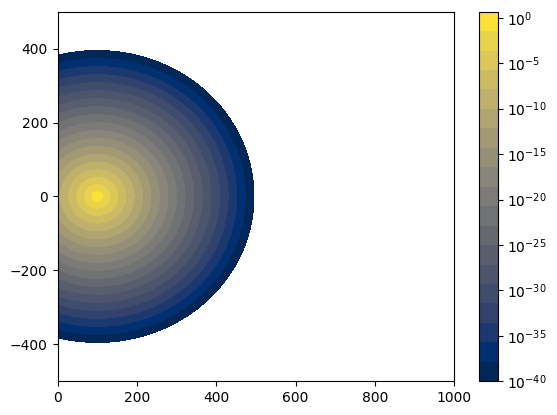

In [44]:
# Визуализация
plt = plot(x_grid, y_grid, concentration, min_concentration=1e-40)
plt.show()